# 🚌 Bus Passenger Counting — Stable ID Edition
### Fixes applied vs original notebook:
- **NMS merge** before tracker (kills pillar-split double detections)
- **StrongSORT** tracker (better occlusion recovery than BoT-SORT/ByteTrack)
- **Minimum box height filter** (removes ghost partial-body tracks)
- **Lost track buffer = 150 frames** (survives stair-navigation disappearance)
- **PROCESS_EVERY_N = 2** (stable 15fps → consistent Kalman filter)
- **Correct TOTAL logic**: TOTAL = ENTRY + EXIT, same person NOT double-counted via ReID gallery
- **EMA embedding update** (running average makes ReID matching more robust)

---
> ⚠️ Run cells **top to bottom**. GPU runtime required (Runtime → Change runtime type → T4 GPU)


## Step 1 — Check GPU

In [1]:
import subprocess, sys
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(" GPU detected!")
    lines = result.stdout.split('\n')
    for l in lines:
        if 'MiB' in l or 'GPU' in l:
            print(l)
else:
    print("  No GPU — go to Runtime → Change runtime type → T4 GPU")
print(f"Python: {sys.version}")


 GPU detected!
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|  GPU   GI   CI              PID   Type   Process name                        GPU Memory |
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## Step 2 — Install Dependencies
> Takes ~2 minutes. Kernel will restart automatically.

In [ ]:
%pip install "torch>=2.3.0" torchvision -q
%pip install ultralytics==8.3.0 -q
%pip install supervision==0.21.0 -q
%pip install boxmot==10.0.84 -q
%pip install opencv-python-headless -q
%pip install gdown lapx scipy -q
%pip install "numpy==1.26.4" --force-reinstall -q

import os
print(" All packages installed — restarting kernel...")
os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 881.3/881.3 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requ

## Step 3 — Import Libraries

In [1]:
import cv2
import numpy as np
import torch
import os, time, collections, functools
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO
import supervision as sv

# Patch torch.load for PyTorch 2.6+ compatibility
_orig_load = torch.load
torch.load = functools.partial(_orig_load, weights_only=False)

print(f" Imports OK")
print(f"   PyTorch : {torch.__version__}")
print(f"   CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports OK
   PyTorch : 2.2.2+cu121
   CUDA    : True
   GPU     : Tesla T4


## Step 4 — Upload Videos
Upload **1.mp4** (side-view door camera) and **2.mp4** (top-view).  
Or update the paths below if already uploaded.


In [2]:
VIDEO_PATH_SIDE = "/content/1.mp4"
VIDEO_PATH_TOP  = "/content/2.mp4"
VIDEO_PATH      = VIDEO_PATH_SIDE   # primary

for label, path in [("Side-view (1.mp4)", VIDEO_PATH_SIDE),
                    ("Top-view  (2.mp4)", VIDEO_PATH_TOP)]:
    cap = cv2.VideoCapture(path)
    W_  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H_  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    FPS_= cap.get(cv2.CAP_PROP_FPS)
    TF_ = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"\n📹 {label}")
    print(f"   Resolution : {W_} x {H_}")
    print(f"   FPS        : {FPS_:.1f}")
    print(f"   Duration   : {TF_/FPS_:.1f}s  ({TF_} frames)")

cap = cv2.VideoCapture(VIDEO_PATH)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
VID_FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f"\nPrimary video: {W}x{H} @ {VID_FPS:.0f}fps")



📹 Side-view (1.mp4)
   Resolution : 1278 x 720
   FPS        : 30.0
   Duration   : 133.2s  (3997 frames)

📹 Top-view  (2.mp4)
   Resolution : 1278 x 720
   FPS        : 30.0
   Duration   : 133.2s  (3997 frames)

Primary video: 1278x720 @ 30fps


## Step 5 — Configuration
**Tune these values for your video. Run Step 6 first to visualise the baseline position.**

| Parameter | Effect |
|---|---|
| `BASELINE_X` | X-pixel of the counting line. Run Step 6 to find correct value. |
| `ROI_POLYGON` | Only count people inside this zone. Ignores outside pedestrians. |
| `REID_THRESHOLD` | 0.55–0.65 = loose match (same person more easily recognised). |
| `MIN_BOX_HEIGHT` | Ignore detections shorter than this — removes ghost partial-body tracks. |
| `LOST_TRACK_BUFFER` | Frames tracker holds a lost track before killing it. Keep at 150. |
| `PROCESS_EVERY_N` | Set to 2 — gives stable 15fps to Kalman filter, reduces GPU load. |


In [57]:
# ── Output paths ─────────────────────────────────────────────────────
OUTPUT_PATH_SIDE = "/content/output_side_counted.mp4"
OUTPUT_PATH_TOP  = "/content/output_top_counted.mp4"
OUTPUT_PATH_DUAL = "/content/output_dual_sidebyside.mp4"
OUTPUT_PATH      = OUTPUT_PATH_SIDE

# ── YOLO model ───────────────────────────────────────────────────────
YOLO_MODEL  = "yolov8l.pt"   # yolov8n=fastest / yolov8l=best accuracy
CONF_THRESH = 0.40
IOU_THRESH  = 0.45

# ── Baseline (vertical counting line) ────────────────────────────────
# Run Step 6 first to find the correct pixel X for your door frame.
# LEFT  of baseline = inside bus  → crossing right-to-left = ENTRY
# RIGHT of baseline = outside/steps → crossing left-to-right = EXIT
BASELINE_X = 620   # ← adjust after Step 6 preview

cap_tmp = cv2.VideoCapture(VIDEO_PATH)
VID_H   = int(cap_tmp.get(cv2.CAP_PROP_FRAME_HEIGHT))
VID_W   = int(cap_tmp.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_FPS = cap_tmp.get(cv2.CAP_PROP_FPS)
cap_tmp.release()

# ── ROI polygon (counting zone) ──────────────────────────────────────
ROI_POLYGON = np.array([
    [0,   200],
    [900, 200],
    [900, 720],
    [0,   720],
], dtype=np.int32)

# ── Top-view settings ────────────────────────────────────────────────
ROI_POLYGON_TOP = np.array([[0,0],[750,0],[750,720],[0,720]], dtype=np.int32)
BASELINE_X_TOP  = 380

# ── Re-ID settings ───────────────────────────────────────────────────
REID_THRESHOLD  = 0.45  # cosine similarity. Lower = more forgiving match
GALLERY_TIMEOUT = 600    # seconds to remember an exited person

# ── Stable-ID fixes (KEY PARAMETERS) ────────────────────────────────
MIN_BOX_HEIGHT     = 100   # ignore detections smaller than this (px) — removes ghost tracks
NMS_MERGE_IOU      = 0.30  # merge overlapping boxes before tracker (kills pillar-split problem)
LOST_TRACK_BUFFER  = 150   # frames tracker holds a lost ID (150 @ 15fps effective = 10 sec)
MIN_TRACK_FRAMES   = 8     # frames before a track is trusted
COOLDOWN_FRAMES    = 90    # min frames between same person crossing twice
BASELINE_BUFFER    = 80   # dead-band px around baseline (stops straddling jitter)

# ── Processing ───────────────────────────────────────────────────────
PROCESS_EVERY_N = 2    # process every 2nd frame → stable ~15fps for Kalman filter
MAX_FRAMES      = None  # None = process full video; set e.g. 900 for testing

# ── Display ──────────────────────────────────────────────────────────
SHOW_ROI_OVERLAY = True
SHOW_TRACK_TRAIL = True
TRAIL_LENGTH     = 40

print(" Configuration loaded")
print(f"   Video           : {VID_W}x{VID_H} @ {VID_FPS:.0f}fps")
print(f"   Baseline X      : {BASELINE_X}px")
print(f"   Min box height  : {MIN_BOX_HEIGHT}px  (ghost track filter)")
print(f"   NMS merge IoU   : {NMS_MERGE_IOU}     (pillar-split fix)")
print(f"   Lost buffer     : {LOST_TRACK_BUFFER} frames (occlusion recovery)")
print(f"   Process every N : {PROCESS_EVERY_N}   (stable Kalman FPS)")
print(f"   ReID threshold  : {REID_THRESHOLD}")


 Configuration loaded
   Video           : 1278x720 @ 30fps
   Baseline X      : 620px
   Min box height  : 100px  (ghost track filter)
   NMS merge IoU   : 0.3     (pillar-split fix)
   Lost buffer     : 150 frames (occlusion recovery)
   Process every N : 2   (stable Kalman FPS)
   ReID threshold  : 0.45


## Step 6 — Visualise Baseline & ROI
Run this, check the yellow line is on the door frame edge. Adjust `BASELINE_X` in Step 5 and re-run if needed.

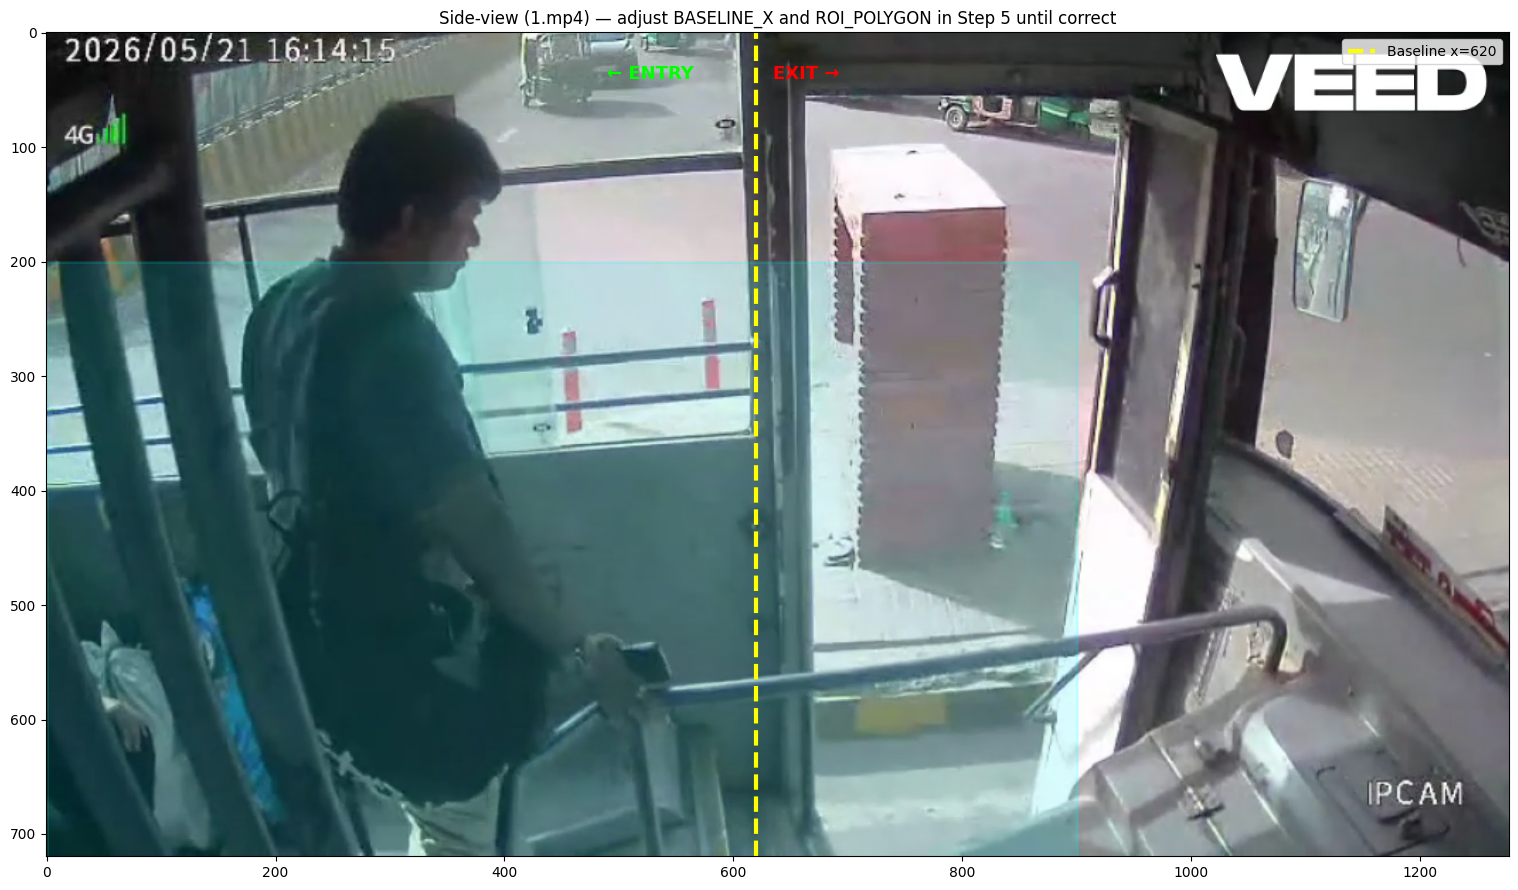

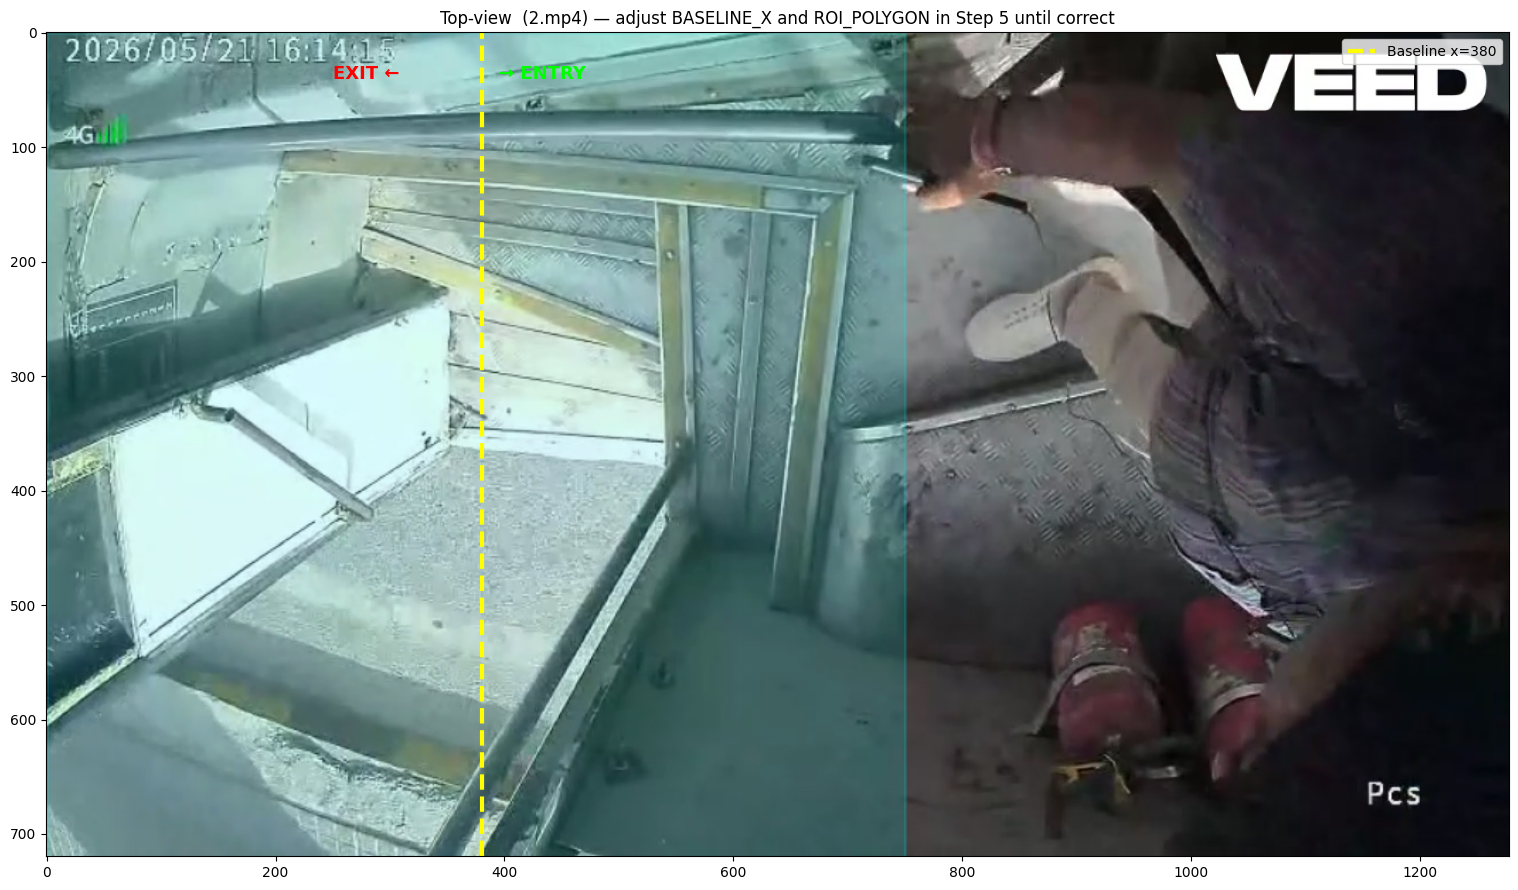

In [58]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

def visualise_config(video_path, baseline_x, roi_polygon, label, frame_num=30):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        print(f"  Could not read frame from {video_path}")
        return
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(frame_rgb)
    ax.axvline(x=baseline_x, color='yellow', linewidth=3, linestyle='--',
               label=f'Baseline x={baseline_x}')
    if video_path == VIDEO_PATH_TOP:
      ax.text(baseline_x - 130, 40, 'EXIT ←',  color='red',  fontsize=13, fontweight='bold')
      ax.text(baseline_x + 15,  40, '→ ENTRY', color='lime', fontsize=13, fontweight='bold')
    else:
      ax.text(baseline_x - 130, 40, '← ENTRY', color='lime', fontsize=13, fontweight='bold')
      ax.text(baseline_x + 15,  40, 'EXIT →',  color='red',  fontsize=13, fontweight='bold')
    poly = MplPolygon(roi_polygon, closed=True, fill=True,
                      facecolor='cyan', alpha=0.15, edgecolor='cyan', linewidth=2)
    ax.add_patch(poly)
    ax.set_title(f'{label} — adjust BASELINE_X and ROI_POLYGON in Step 5 until correct')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

visualise_config(VIDEO_PATH_SIDE, BASELINE_X,     ROI_POLYGON,     "Side-view (1.mp4)")
visualise_config(VIDEO_PATH_TOP,  BASELINE_X_TOP, ROI_POLYGON_TOP, "Top-view  (2.mp4)")


## Step 7 — Load YOLOv8 Model

In [7]:
print(f"Loading {YOLO_MODEL} ...")
model = YOLO(YOLO_MODEL)
model.to('cuda' if torch.cuda.is_available() else 'cpu')
print(f" {YOLO_MODEL} loaded on {'GPU' if torch.cuda.is_available() else 'CPU'}")


Loading yolov8l.pt ...


100%|██████████| 83.7M/83.7M [00:02<00:00, 34.9MB/s]


 yolov8l.pt loaded on GPU


## Step 8 — Load OSNet Re-ID Model

In [8]:
from boxmot.appearance.reid_auto_backend import ReidAutoBackend

DEVICE     = '0' if torch.cuda.is_available() else 'cpu'
reid_model = ReidAutoBackend(
    weights=Path("osnet_ain_x1_0_msmt17.pt"),
    device=DEVICE,
    half=False
)
print(f" OSNet Re-ID loaded  (device={DEVICE})")


2026-05-29 05:19:38.221 | INFO     | boxmot.utils.torch_utils:select_device:52 - Yolo Tracking v10.0.83 🚀 Python-3.12.13 torch-2.2.2+cu121
CUDA:0 (Tesla T4, 14913MiB)
Downloading...
From: https://drive.google.com/uc?id=1SigwBE6mPdqiJMqhuIY4aqC7--5CsMal
To: /content/osnet_ain_x1_0_msmt17.pt
100%|██████████| 17.3M/17.3M [00:00<00:00, 44.5MB/s]
2026-05-29 05:19:40.566 | SUCCESS  | boxmot.appearance.reid_model_factory:load_pretrained_weights:183 - Loaded pretrained weights from osnet_ain_x1_0_msmt17.pt


 OSNet Re-ID loaded  (device=0)


## Step 9 — Load StrongSORT Tracker
StrongSORT uses appearance embeddings on **every frame** (not just on track loss like BoT-SORT).  
This makes it significantly more stable through occlusion and pose changes.


In [59]:
from boxmot import BoTSORT

tracker = BoTSORT(
    model_weights=Path("osnet_ain_x1_0_msmt17.pt"),
    device='0' if torch.cuda.is_available() else 'cpu',
    fp16=False,
    track_high_thresh=0.35,
    track_low_thresh=0.15,
    new_track_thresh=0.35,
    track_buffer=LOST_TRACK_BUFFER,
    match_thresh=0.9,
    proximity_thresh=0.7,
    appearance_thresh=0.20,
)
print(f" StrongSORT loaded")
print(f"   max_age (lost buffer) : {LOST_TRACK_BUFFER} frames")
print(f"   n_init (min frames)   : {MIN_TRACK_FRAMES} frames")


2026-05-29 06:30:59.092 | INFO     | boxmot.utils.torch_utils:select_device:52 - Yolo Tracking v10.0.83 🚀 Python-3.12.13 torch-2.2.2+cu121
CUDA:0 (Tesla T4, 14913MiB)
2026-05-29 06:30:59.246 | SUCCESS  | boxmot.appearance.reid_model_factory:load_pretrained_weights:183 - Loaded pretrained weights from osnet_ain_x1_0_msmt17.pt


 StrongSORT loaded
   max_age (lost buffer) : 150 frames
   n_init (min frames)   : 8 frames


## Step 10 — Helper Functions
Includes the **NMS merge function** — the most important fix for your pillar-split problem.


In [60]:
def merge_overlapping_detections(detections, iou_thresh=NMS_MERGE_IOU):
    """
    Merge overlapping boxes BEFORE passing to tracker.
    This fixes the pillar-split problem where YOLO creates two boxes for one person.
    Any two boxes with IoU > iou_thresh are merged into a single larger box.
    """
    if len(detections) <= 1:
        return detections

    boxes = detections.xyxy.copy()
    confs = detections.confidence.copy()
    suppressed = set()
    merged_list = []

    for i in range(len(boxes)):
        if i in suppressed:
            continue
        merged = boxes[i].copy()
        best_conf = confs[i]
        for j in range(i + 1, len(boxes)):
            if j in suppressed:
                continue
            xi1 = max(boxes[i][0], boxes[j][0])
            yi1 = max(boxes[i][1], boxes[j][1])
            xi2 = min(boxes[i][2], boxes[j][2])
            yi2 = min(boxes[i][3], boxes[j][3])
            inter_w = max(0.0, xi2 - xi1)
            inter_h = max(0.0, yi2 - yi1)
            inter   = inter_w * inter_h
            area_i  = (boxes[i][2]-boxes[i][0]) * (boxes[i][3]-boxes[i][1])
            area_j  = (boxes[j][2]-boxes[j][0]) * (boxes[j][3]-boxes[j][1])
            iou     = inter / (area_i + area_j - inter + 1e-6)
            if iou > iou_thresh:
                # Union of both boxes
                merged[0] = min(merged[0], boxes[j][0])
                merged[1] = min(merged[1], boxes[j][1])
                merged[2] = max(merged[2], boxes[j][2])
                merged[3] = max(merged[3], boxes[j][3])
                best_conf = max(best_conf, confs[j])
                suppressed.add(j)
        merged_list.append((merged, best_conf))

    new_xyxy = np.array([m[0] for m in merged_list], dtype=np.float32)
    new_conf = np.array([m[1] for m in merged_list], dtype=np.float32)
    new_cls  = np.zeros(len(merged_list), dtype=int)

    return sv.Detections(xyxy=new_xyxy, confidence=new_conf, class_id=new_cls)


def filter_min_height(detections, min_height=MIN_BOX_HEIGHT):
    """Remove detections shorter than min_height pixels (ghost/partial-body tracks)."""
    if len(detections) == 0:
        return detections
    heights = detections.xyxy[:, 3] - detections.xyxy[:, 1]
    return detections[heights >= min_height]


def point_in_polygon(x, y, polygon):
    return cv2.pointPolygonTest(polygon, (float(x), float(y)), False) >= 0


def draw_hud(frame, entry_count, exit_count, total_count, fps_display):
    """Entry / Exit / Total HUD. TOTAL = ENTRY + EXIT (unique persons, no double-count)."""
    cv2.rectangle(frame, (10, 10), (340, 135), (0, 0, 0), -1)
    cv2.rectangle(frame, (10, 10), (340, 135), (255, 255, 255), 1)
    cv2.putText(frame, f"ENTRY  : {entry_count}",
                (20, 48),  cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0),   2)
    cv2.putText(frame, f"EXIT   : {exit_count}",
                (20, 85),  cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 100, 255), 2)
    cv2.putText(frame, f"TOTAL  : {total_count}",
                (20, 122), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
    h, w = frame.shape[:2]
    cv2.putText(frame, f"FPS: {fps_display:.1f}",
                (w - 130, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)
    return frame


def draw_roi(frame, polygon):
    overlay = frame.copy()
    cv2.fillPoly(overlay, [polygon], (0, 255, 200))
    cv2.addWeighted(overlay, 0.07, frame, 0.93, 0, frame)
    cv2.polylines(frame, [polygon], True, (0, 255, 200), 2)
    return frame


print(" Helper functions ready")
print(f"   NMS merge IoU threshold : {NMS_MERGE_IOU}")
print(f"   Min box height filter   : {MIN_BOX_HEIGHT}px")


 Helper functions ready
   NMS merge IoU threshold : 0.3
   Min box height filter   : 100px


## Step 11 — Re-ID Gallery
Stores appearance embeddings of persons who have crossed the baseline.  
When the same person crosses again → recognised → **not double-counted**.  
Uses **EMA (exponential moving average)** embedding updates for more robust matching.


In [61]:
import time
from scipy.spatial.distance import cosine

class ReIDGallery:
    """
    Tracks unique persons across entry/exit events.
    - Active tracks: currently visible, have a person_id
    - Gallery: exited persons remembered by their embedding
    - EMA updates: embedding improves over time as more crops are seen
    """
    def __init__(self, threshold=0.58, timeout_sec=600):
        self.threshold   = threshold
        self.timeout_sec = timeout_sec
        self.gallery     = {}     # person_id -> {embedding, exit_time}
        self.active      = {}     # track_id  -> person_id
        self.embeddings  = {}     # track_id  -> current embedding (EMA)
        self.next_pid    = 1

    def get_embedding(self, frame, bbox_xyxy):
        """Extract OSNet embedding by passing full frame + bbox to boxmot backend."""
        x1, y1, x2, y2 = [int(v) for v in bbox_xyxy]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(frame.shape[1]-1, x2), min(frame.shape[0]-1, y2)
        if (x2 - x1) < 20 or (y2 - y1) < 40:
            return None
        try:
            boxes = np.array([[x1, y1, x2, y2]], dtype=np.float32)
            emb = reid_model.model.get_features(boxes, frame)
            emb = emb[0]
            norm = np.linalg.norm(emb)
            return emb / (norm + 1e-6)
        except Exception as e:
            print(f"  [EMB ERROR] {type(e).__name__}: {e}")
            return None

    def update_embedding_ema(self, track_id, new_emb, alpha=0.85):
        """
        Exponential moving average embedding update.
        alpha=0.85 means 85% old + 15% new each update.
        This makes the embedding more stable and representative over time.
        """
        if track_id not in self.embeddings or self.embeddings[track_id] is None:
            self.embeddings[track_id] = new_emb
        else:
            ema = alpha * self.embeddings[track_id] + (1 - alpha) * new_emb
            norm = np.linalg.norm(ema)
            self.embeddings[track_id] = ema / (norm + 1e-6)

    def match_or_new(self, track_id):
        """
        Assign a person_id to a track.
        1. If track already active → return its person_id
        2. Search gallery for embedding match → restore old person_id (returning person)
        3. No match → assign new person_id
        Returns (person_id, is_returning)
        """
        if track_id in self.active:
            return self.active[track_id], False

        emb = self.embeddings.get(track_id, None)
        best_pid, best_sim = None, -1
        now = time.time()
        expired = [pid for pid, d in self.gallery.items()
                   if now - d['exit_time'] > self.timeout_sec]
        for pid in expired:
            del self.gallery[pid]

        if emb is not None:
            for pid, data in self.gallery.items():
                if data['embedding'] is None:
                    continue
                sim = 1 - cosine(emb, data['embedding'])
                if sim > best_sim:
                    best_sim, best_pid = sim, pid

        if best_pid is not None and best_sim >= self.threshold:
            self.active[track_id] = best_pid
            del self.gallery[best_pid]
            print(f"  [REID MATCH] track={track_id} matched person_id={best_pid}  sim={best_sim:.3f}")
            return best_pid, True
        else:
            pid = self.next_pid
            self.next_pid += 1
            self.active[track_id] = pid
            if best_pid is not None:
                print(f"  [REID FAIL]  track={track_id} best_sim={best_sim:.3f} < threshold={self.threshold}  new pid={pid}")
            else:
                print(f"  [REID NEW]   track={track_id} gallery_empty → new pid={pid}")
            return pid, False

    def mark_exited(self, track_id):
        """Move track from active → gallery on exit."""
        if track_id not in self.active:
            return
        pid = self.active.pop(track_id)
        emb = self.embeddings.get(track_id, None)
        if emb is None:
            # No embedding stored — try to recover from any previous embedding
            print(f"  [WARN] person_id={pid} exited with no embedding — ReID won't work for re-entry")
        self.gallery[pid] = {'embedding': emb, 'exit_time': time.time()}
        self.embeddings.pop(track_id, None)
        print(f"  [GALLERY] person_id={pid} stored  gallery_size={len(self.gallery)}")

    def remove_active(self, track_id):
        """Remove a track from active without storing in gallery (track lost without exit)."""
        self.active.pop(track_id, None)
        self.embeddings.pop(track_id, None)


gallery = ReIDGallery(threshold=REID_THRESHOLD, timeout_sec=GALLERY_TIMEOUT)
print(f" ReID Gallery initialised")
print(f"   Similarity threshold : {REID_THRESHOLD}  (tune down if same person not matched)")
print(f"   Gallery timeout      : {GALLERY_TIMEOUT}s")


 ReID Gallery initialised
   Similarity threshold : 0.45  (tune down if same person not matched)
   Gallery timeout      : 600s


## Step 12 — Set Up Annotators

In [62]:
# Each track ID gets a distinct colour automatically
box_annotator   = sv.BoundingBoxAnnotator(thickness=2, color=sv.ColorPalette.DEFAULT)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1, text_padding=3,
                                    color=sv.ColorPalette.DEFAULT)
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=TRAIL_LENGTH,
                                    color=sv.ColorPalette.DEFAULT) if SHOW_TRACK_TRAIL else None

print(" Annotators ready")


 Annotators ready


## Step 13 — Main Processing Loop ▶️
**How TOTAL is calculated correctly:**
- Each unique `person_id` (assigned by ReID gallery) is tracked in a set `counted_person_ids`
- ENTRY increments when a NEW person_id crosses right→left for the first time
- EXIT increments when a person_id crosses left→right (any time, cooldown-gated)
- If the SAME person re-enters: ReID gallery matches them → same `person_id` → ENTRY blocked → no double-count
- **TOTAL = ENTRY + EXIT** counts total crossing events by unique persons

⏱️ On T4 GPU with PROCESS_EVERY_N=2: ~18–25fps. 2-min video takes ~2–3 minutes.


In [38]:
print([m for m in dir(reid_model) if not m.startswith('__')])

['check_suffix', 'device', 'engine', 'forward', 'get_backend', 'half', 'jit', 'model', 'model_type', 'onnx', 'pt', 'tflite', 'weights', 'xml']


In [45]:
print(type(reid_model.model))
print([m for m in dir(reid_model.model) if not m.startswith('__')])

<class 'boxmot.appearance.backends.pytorch_backend.PyTorchBackend'>
['checker', 'cuda', 'device', 'download_model', 'forward', 'get_crops', 'get_features', 'half', 'inference_postprocess', 'inference_preprocess', 'load_model', 'model', 'model_name', 'nhwc', 'to_numpy', 'warmup', 'weights']


In [52]:
# test on first frame
cap_test = cv2.VideoCapture(VIDEO_PATH)
ret, frame_test = cap_test.read()
cap_test.release()

# dummy crop
crop_test = frame_test[100:400, 100:400]
result = reid_model.model.get_features(crop_test[np.newaxis], frame_test)
print(type(result))
print(len(result) if hasattr(result, '__len__') else 'scalar')
if hasattr(result, 'shape'):
    print('shape:', result.shape)
elif isinstance(result, (list, tuple)):
    for i, r in enumerate(result):
        print(f'  result[{i}] type={type(r)} shape={getattr(r, "shape", "?")}')

ValueError: too many values to unpack (expected 4)

In [ ]:
# ── Reset all state for a clean run ──────────────────────────────────
gallery         = ReIDGallery(threshold=REID_THRESHOLD, timeout_sec=GALLERY_TIMEOUT)
try:
    tracker.reset()
except AttributeError:
    pass

# ── Counters ─────────────────────────────────────────────────────────
entry_count   = 0
exit_count    = 0

# ── Per-track state ───────────────────────────────────────────────────
track_frames      = defaultdict(int)   # track_id → frame count alive
track_person_ids  = {}                 # track_id → person_id
track_last_side   = {}                 # track_id → 'left' | 'right'
track_labels      = {}                 # track_id → display label string

# ── Per-person state ──────────────────────────────────────────────────
#
#  COUNTING LOGIC EXPLAINED:
#  - entry_person_ids  : set of person_ids that have ENTERED  (right→left)
#  - exit_person_ids   : set of person_ids that have EXITED   (left→right)
#  - A person_id can appear in BOTH sets (entered then exited = 2 events)
#  - But same person re-entering gets SAME person_id → blocked from counting again
#  - TOTAL = entry_count + exit_count  (unique crossing events, no double-count)
#
entry_person_ids  = set()   # person_ids that have crossed as ENTRY
exit_person_ids   = set()   # person_ids that have crossed as EXIT
crossing_cooldown = {}      # person_id → last frame they crossed (any direction)

# ── Video I/O ─────────────────────────────────────────────────────────
cap     = cv2.VideoCapture(VIDEO_PATH)
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if MAX_FRAMES:
    TOTAL = min(TOTAL, MAX_FRAMES)

fourcc  = cv2.VideoWriter_fourcc(*'mp4v')
out_vid = cv2.VideoWriter(OUTPUT_PATH, fourcc, VID_FPS, (W, H))

frame_idx = 0
t_start   = time.time()
fps_hist  = collections.deque(maxlen=30)

print(f"▶  Processing {TOTAL} frames ({TOTAL/VID_FPS:.1f}s video) ...")
print(f"   Output → {OUTPUT_PATH}")
print()

# ─── Main Loop ────────────────────────────────────────────────────────
while True:
    ret, frame = cap.read()
    if not ret or (MAX_FRAMES and frame_idx >= MAX_FRAMES):
        break

    frame_idx += 1
    t0 = time.time()

    # ── Skip every other frame (stable Kalman FPS) ────────────────────
    # ── Skip every other frame (stable Kalman FPS) ────────────────────
    if PROCESS_EVERY_N > 1 and frame_idx % PROCESS_EVERY_N != 0:
        continue   # skip entirely — do NOT write raw frame to output

    # ── YOLOv8 Detection ──────────────────────────────────────────────
    results    = model(frame, classes=[0], conf=CONF_THRESH,
                       iou=IOU_THRESH, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    # ── ROI filter ────────────────────────────────────────────────────
    if len(detections) > 0:
        cx = (detections.xyxy[:, 0] + detections.xyxy[:, 2]) / 2
        cy = (detections.xyxy[:, 1] + detections.xyxy[:, 3]) / 2
        in_roi = np.array([point_in_polygon(cx[i], cy[i], ROI_POLYGON)
                           for i in range(len(detections))])
        detections = detections[in_roi]

    # ── FIX 1: Minimum box height filter (removes ghost tracks) ───────
    detections = filter_min_height(detections, MIN_BOX_HEIGHT)

    # ── FIX 2: NMS merge overlapping boxes (kills pillar-split problem)
    if len(detections) > 1:
        detections = merge_overlapping_detections(detections, NMS_MERGE_IOU)

    # ── StrongSORT update ─────────────────────────────────────────────
    if len(detections) > 0:
        dets = np.column_stack([
            detections.xyxy,
            detections.confidence,
            detections.class_id.astype(float)
        ])
    else:
        dets = np.empty((0, 6))

    tracks = tracker.update(dets, frame)
    if frame_idx % 100 == 0:
        print(f"frame={frame_idx}  dets={len(dets)}  tracks={0 if tracks is None else len(tracks)}")
    if tracks is None or len(tracks) == 0:
        # No active tracks — still draw frame
        if SHOW_ROI_OVERLAY:
            frame = draw_roi(frame, ROI_POLYGON)
        cv2.line(frame, (BASELINE_X, 0), (BASELINE_X, H), (0, 255, 255), 3)
        cv2.putText(frame, "ENTRY <-", (BASELINE_X-130, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, "-> EXIT", (BASELINE_X+10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 100, 255), 2)
        fps_hist.append(1.0 / max(time.time()-t0, 1e-6))
        total_count = entry_count + exit_count
        frame = draw_hud(frame, entry_count, exit_count, total_count, np.mean(fps_hist))
        out_vid.write(frame)
        continue

    # Rebuild sv.Detections from StrongSORT output [x1,y1,x2,y2,id,conf,cls,idx]
    # Rebuild sv.Detections from StrongSORT output — safe unpacking
    tracks = np.atleast_2d(tracks)
    xyxy      = tracks[:, 0:4].astype(float)
    track_ids = tracks[:, 4].astype(int)
    confs     = tracks[:, 5].astype(float) if tracks.shape[1] > 5 else np.ones(len(tracks))
    cls_ids   = tracks[:, 6].astype(int)   if tracks.shape[1] > 6 else np.zeros(len(tracks), dtype=int)
    detections = sv.Detections(
        xyxy=xyxy, confidence=confs,
        class_id=cls_ids, tracker_id=track_ids
    )

    # ── Re-ID embedding extraction + EMA update ────────────────────────
    for i, track_id in enumerate(track_ids):
        track_frames[track_id] += 1
        # Extract embedding every 8 frames (save GPU, still frequent enough for EMA)
        emb = gallery.get_embedding(frame, detections.xyxy[i])
        if emb is not None:
            gallery.update_embedding_ema(track_id, emb)
        else:
            if track_frames[track_id] <= 5:
                print(f"  [EMB FAIL] track={track_id} frame={frame_idx} bbox={detections.xyxy[i].astype(int)}")

    # ── Person ID assignment + crossing logic ──────────────────────────
    labels = []
    for i, track_id in enumerate(track_ids):
        bbox = detections.xyxy[i]
        cx_det = (bbox[0] + bbox[2]) / 2

        # Side determination with dead-band buffer
        if cx_det < BASELINE_X - BASELINE_BUFFER:
            side = 'left'
        elif cx_det > BASELINE_X + BASELINE_BUFFER:
            side = 'right'
        else:
            side = track_last_side.get(track_id, 'right')  # hold last known side while straddling

        # Assign person_id once track is old enough to trust
        if track_id not in track_person_ids:
            if track_frames[track_id] >= MIN_TRACK_FRAMES:
                pid, returning = gallery.match_or_new(track_id)
                track_person_ids[track_id] = pid
                if returning:
                    track_labels[track_id] = f"ID:{pid}(return)"
                    print(f"  [RETURNING]  person_id={pid}  track={track_id}  frame={frame_idx}")
                else:
                    track_labels[track_id] = f"ID:{pid}"
            else:
                track_labels[track_id] = f"ID:?"
                track_last_side[track_id] = side
                labels.append(track_labels[track_id])
                continue

        pid      = track_person_ids[track_id]
        prev_side = track_last_side.get(track_id, None)
        track_last_side[track_id] = side

        # ── Crossing event detection ──────────────────────────────────
        if prev_side is not None and prev_side != side:
            last_cross = crossing_cooldown.get(pid, -9999)
            on_cooldown = (frame_idx - last_cross) < COOLDOWN_FRAMES

            if not on_cooldown:
                if prev_side == 'right' and side == 'left':
                    # ── ENTRY: outside → inside ──────────────────────
                    if pid not in entry_person_ids:
                        # First time this person enters
                        entry_count += 1
                        entry_person_ids.add(pid)
                        crossing_cooldown[pid] = frame_idx
                        track_labels[track_id] = f"ID:{pid} ENTRY"
                        print(f"  [ENTRY]  person_id={pid}  track={track_id}  "
                              f"frame={frame_idx}  ENTRY={entry_count}  EXIT={exit_count}  "
                              f"TOTAL={entry_count+exit_count}")
                    else:
                        # Already entered before — re-entry, do NOT count again
                        crossing_cooldown[pid] = frame_idx
                        track_labels[track_id] = f"ID:{pid}(re-entry)"
                        print(f"  [RE-ENTRY blocked]  person_id={pid}  frame={frame_idx}")

                elif prev_side == 'left' and side == 'right':
                    # ── EXIT: inside → outside ───────────────────────
                    crossing_cooldown[pid] = frame_idx
                    gallery.mark_exited(track_id)
                    track_person_ids.pop(track_id, None)
                    if pid not in exit_person_ids:
                        exit_count += 1
                        exit_person_ids.add(pid)
                        track_labels[track_id] = f"ID:{pid} EXIT"
                        print(f"  [EXIT]   person_id={pid}  track={track_id}  "
                              f"frame={frame_idx}  ENTRY={entry_count}  EXIT={exit_count}  "
                              f"TOTAL={entry_count+exit_count}")
                    else:
                        track_labels[track_id] = f"ID:{pid}(re-exit blocked)"
                        print(f"  [RE-EXIT blocked]  person_id={pid}  frame={frame_idx}")
            else:
                track_labels[track_id] = f"ID:{pid}(cooldown)"

        labels.append(track_labels.get(track_id, f"ID:{track_id}"))

    # ── Draw ──────────────────────────────────────────────────────────
    if SHOW_ROI_OVERLAY:
        frame = draw_roi(frame, ROI_POLYGON)

    cv2.line(frame, (BASELINE_X, 0), (BASELINE_X, H), (0, 255, 255), 3)
    cv2.putText(frame, "ENTRY <-", (BASELINE_X-130, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(frame, "-> EXIT",  (BASELINE_X+10,  25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 100, 255), 2)

    if len(detections) > 0:
        if SHOW_TRACK_TRAIL and trace_annotator:
            frame = trace_annotator.annotate(frame, detections)
        frame = box_annotator.annotate(frame, detections)
        if labels:
            frame = label_annotator.annotate(frame, detections,
                                             labels=labels[:len(detections)])

    fps_hist.append(1.0 / max(time.time() - t0, 1e-6))
    total_count = entry_count + exit_count
    frame = draw_hud(frame, entry_count, exit_count, total_count, np.mean(fps_hist))
    out_vid.write(frame)

    if frame_idx % 150 == 0:
        elapsed = time.time() - t_start
        pct     = 100 * frame_idx / TOTAL
        eta     = elapsed / frame_idx * (TOTAL - frame_idx)
        print(f"  {pct:5.1f}%  frame {frame_idx}/{TOTAL}  "
              f"Entry={entry_count}  Exit={exit_count}  "
              f"Total={entry_count+exit_count}  ETA {eta:.0f}s")

cap.release()
out_vid.release()

elapsed_total = time.time() - t_start
print()
print("=" * 55)
print(f"  Done in {elapsed_total:.1f}s")
print(f"   ENTRY  : {entry_count}")
print(f"   EXIT   : {exit_count}")
print(f"   TOTAL  : {entry_count + exit_count}  (= ENTRY + EXIT, no double-count)")
print(f"   Output : {OUTPUT_PATH}")
print("=" * 55)


▶  Processing 3997 frames (133.2s video) ...
   Output → /content/output_side_counted.mp4

  [REID NEW]   track=1 gallery_empty → new pid=1
  [GALLERY] person_id=1 stored  gallery_size=1
  [EXIT]   person_id=1  track=1  frame=84  ENTRY=0  EXIT=1  TOTAL=1
  [REID MATCH] track=1 matched person_id=1  sim=0.875
  [RETURNING]  person_id=1  track=1  frame=86
frame=100  dets=1  tracks=1
  [REID NEW]   track=2 gallery_empty → new pid=2
    3.8%  frame 150/3997  Entry=0  Exit=1  Total=1  ETA 233s
  [GALLERY] person_id=2 stored  gallery_size=1
  [EXIT]   person_id=2  track=2  frame=164  ENTRY=0  EXIT=2  TOTAL=2
  [REID MATCH] track=2 matched person_id=2  sim=0.845
  [RETURNING]  person_id=2  track=2  frame=166
frame=200  dets=3  tracks=3
  [REID NEW]   track=3 gallery_empty → new pid=3
  [REID NEW]   track=4 gallery_empty → new pid=4
  [REID NEW]   track=6 gallery_empty → new pid=5
  [GALLERY] person_id=5 stored  gallery_size=1
  [EXIT]   person_id=5  track=6  frame=276  ENTRY=0  EXIT=3  TOTAL=3

## Step 14 — Top-View Video Processing (Video 2)
Same stable-ID improvements applied.

In [ ]:
from boxmot import StrongSort

tracker_top = StrongSort(
    model_weights=Path("osnet_ain_x1_0_msmt17.pt"),
    device='0' if torch.cuda.is_available() else 'cpu',
    fp16=False,
    max_age=LOST_TRACK_BUFFER,
    n_init=MIN_TRACK_FRAMES,
)

cap_top = cv2.VideoCapture(VIDEO_PATH_TOP)
W_top   = int(cap_top.get(cv2.CAP_PROP_FRAME_WIDTH))
H_top   = int(cap_top.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_top = cap_top.get(cv2.CAP_PROP_FPS)
TOT_top = int(cap_top.get(cv2.CAP_PROP_FRAME_COUNT))

out_top = cv2.VideoWriter(OUTPUT_PATH_TOP,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          FPS_top, (W_top, H_top))

fidx = 0
print(f"Processing top-view ({TOT_top} frames) ...")
while True:
    ret, frame = cap_top.read()
    if not ret:
        break
    fidx += 1
    if fidx % PROCESS_EVERY_N != 0:
        out_top.write(frame)
        continue

    results    = model(frame, classes=[0], conf=CONF_THRESH, iou=IOU_THRESH, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    if len(detections) > 0:
        cx = (detections.xyxy[:,0]+detections.xyxy[:,2])/2
        cy = (detections.xyxy[:,1]+detections.xyxy[:,3])/2
        in_roi = np.array([point_in_polygon(cx[i],cy[i],ROI_POLYGON_TOP)
                           for i in range(len(detections))])
        detections = detections[in_roi]
        detections = filter_min_height(detections, MIN_BOX_HEIGHT)
        if len(detections) > 1:
            detections = merge_overlapping_detections(detections, NMS_MERGE_IOU)

    if len(detections) > 0:
        dets = np.column_stack([detections.xyxy,
                                detections.confidence,
                                detections.class_id.astype(float)])
    else:
        dets = np.empty((0,6))

    tracks = tracker_top.update(dets, frame)
    if tracks is not None and len(tracks) > 0:
        detections = sv.Detections(
            xyxy=tracks[:,0:4], confidence=tracks[:,5],
            class_id=tracks[:,6].astype(int), tracker_id=tracks[:,4].astype(int)
        )
        frame = box_annotator.annotate(frame, detections)
        if SHOW_TRACK_TRAIL and trace_annotator:
            frame = trace_annotator.annotate(frame, detections)

    frame = draw_roi(frame, ROI_POLYGON_TOP)
    cv2.line(frame, (BASELINE_X_TOP,0),(BASELINE_X_TOP,H_top),(0,255,255),3)
    cv2.putText(frame,"EXIT <-",(BASELINE_X_TOP-130,25),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,100,255),2)
    cv2.putText(frame,"-> ENTRY",(BASELINE_X_TOP+10,25),
                cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
    cv2.putText(frame,"TOP VIEW",(W_top-200,H_top-20),
                cv2.FONT_HERSHEY_SIMPLEX,1.0,(0,255,255),2)
    out_top.write(frame)

cap_top.release()
out_top.release()
print(f" Top-view saved → {OUTPUT_PATH_TOP}")


## Step 15 — Merge Side-by-Side Dual Video

In [ ]:
print("Merging side-by-side ...")
cap_s = cv2.VideoCapture(OUTPUT_PATH_SIDE)
cap_t = cv2.VideoCapture(OUTPUT_PATH_TOP)
W_s=int(cap_s.get(cv2.CAP_PROP_FRAME_WIDTH)); H_s=int(cap_s.get(cv2.CAP_PROP_FRAME_HEIGHT))
W_t=int(cap_t.get(cv2.CAP_PROP_FRAME_WIDTH)); H_t=int(cap_t.get(cv2.CAP_PROP_FRAME_HEIGHT))
DUAL_H=H_s; W_t_new=int(W_t*(DUAL_H/H_t)); DUAL_W=W_s+W_t_new
out_dual=cv2.VideoWriter(OUTPUT_PATH_DUAL,cv2.VideoWriter_fourcc(*'mp4v'),VID_FPS,(DUAL_W,DUAL_H))
while True:
    ret_s,fs=cap_s.read(); ret_t,ft=cap_t.read()
    if not ret_s or not ret_t: break
    ft_r=cv2.resize(ft,(W_t_new,DUAL_H))
    cv2.putText(fs,"CAM1: SIDE",(10,H_s-15),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,0),2)
    cv2.putText(ft_r,"CAM2: TOP",(10,DUAL_H-15),cv2.FONT_HERSHEY_SIMPLEX,0.8,(255,255,0),2)
    combined=np.hstack([fs,ft_r])
    cv2.line(combined,(W_s,0),(W_s,DUAL_H),(255,255,255),3)
    out_dual.write(combined)
cap_s.release(); cap_t.release(); out_dual.release()
print(f"✅ Dual video saved → {OUTPUT_PATH_DUAL}  ({DUAL_W}x{DUAL_H})")


## Step 16 — Re-encode to H.264 (for playback compatibility)

In [ ]:
PLAYABLE_SIDE = "/content/output_side_h264.mp4"
PLAYABLE_TOP  = "/content/output_top_h264.mp4"
PLAYABLE_DUAL = "/content/output_dual_h264.mp4"

os.system(f"ffmpeg -y -i {OUTPUT_PATH_SIDE} -vcodec libx264 -crf 23 {PLAYABLE_SIDE} -loglevel quiet")
os.system(f"ffmpeg -y -i {OUTPUT_PATH_TOP}  -vcodec libx264 -crf 23 {PLAYABLE_TOP}  -loglevel quiet")
os.system(f"ffmpeg -y -i {OUTPUT_PATH_DUAL} -vcodec libx264 -crf 23 {PLAYABLE_DUAL} -loglevel quiet")

print("✅ All 3 videos encoded to H.264:")
print(f"   Side-view → {PLAYABLE_SIDE}")
print(f"   Top-view  → {PLAYABLE_TOP}")
print(f"   Dual view → {PLAYABLE_DUAL}")


## Step 17 — Download Output Videos

In [ ]:
from google.colab import files
for path, name in [(PLAYABLE_SIDE, "side-view"),
                   (PLAYABLE_TOP,  "top-view"),
                   (PLAYABLE_DUAL, "dual side-by-side")]:
    if os.path.exists(path):
        print(f"Downloading {name} ...")
        files.download(path)
    else:
        print(f"⚠️  {name} not found: {path}")


## Step 18 — Final Summary Report

In [ ]:
print("╔══════════════════════════════════════════════════════╗")
print("║       BUS PASSENGER COUNTING — STABLE ID EDITION     ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Video          : {os.path.basename(VIDEO_PATH):<35}║")
print(f"║  Duration       : {TOTAL/VID_FPS:<5.1f}s                              ║")
print(f"║  Baseline X     : {BASELINE_X}px                              ║")
print(f"║  ReID threshold : {REID_THRESHOLD}                               ║")
print(f"║  Min box height : {MIN_BOX_HEIGHT}px                             ║")
print(f"║  NMS merge IoU  : {NMS_MERGE_IOU}                              ║")
print(f"║  Lost buffer    : {LOST_TRACK_BUFFER} frames                         ║")
print("╠══════════════════════════════════════════════════════╣")
total = entry_count + exit_count
print(f"║   ENTRY   : {entry_count:<42}║")
print(f"║   EXIT    : {exit_count:<42}║")
print(f"║   TOTAL   : {total:<42}║")
print(f"║   (TOTAL = ENTRY + EXIT, same person not counted twice)║")
print("╠══════════════════════════════════════════════════════╣")
net = entry_count - exit_count
print(f"║  Net on bus right now (ENTRY - EXIT) : {net:<14}║")
print(f"║  Unique person IDs assigned by ReID  : {gallery.next_pid-1:<14}║")
print(f"║  Currently in gallery (exited)       : {len(gallery.gallery):<14}║")
print(f"║  Currently active tracks             : {len(gallery.active):<14}║")
print("╚══════════════════════════════════════════════════════╝")
